# PyPSA Beispiel 6

Sie haben die Aufgabe die Transformation der Stromversorgung für ein fiktives Land zu planen. Dabei sollen Sie in 10 Jahresschritten bis zum Jahr 2050 abschätzen, welche Erzeugungs- und Speicherkapazität benötigt wird. 
Im Jahr 2020 besteht der Erzeugungspark aus Kohle, Gas, Wind und PV. Die Kohle- und Gaskraftwerke sollen im Jahr 2030 und 2040 vom Netz gehen und durch PV, Wind, Batteriespeicher und H2-Kraftwerke ersetzt werden.



Hinweise:
* Zur Vereinfachung der Betrachtung geht es nur um den Stromsektor. 
* Sie können Annehmen, dass sich das Lastprofil nicht grundsätzlich ändert und für die Betrachtung hier in allen Zeiträumen gültig ist.
* Es soll keine Übertragung über Netze betrachtet werden. Betrachten Sie das System als einen Knoten für das gesamte Land
* Verwenden Sie eine Schleife um die zusätzlichen Komponenten hinzuzufügen, dies ist übersichtlicher

Systemskizze für ein Jahr:

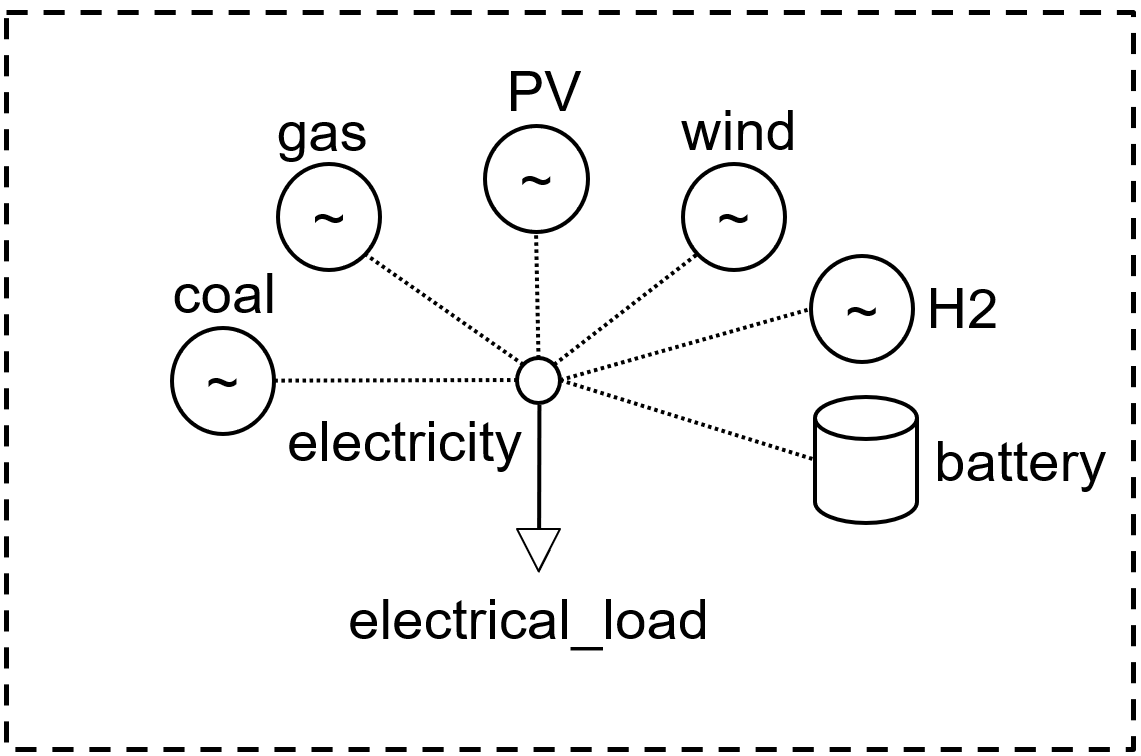

Importieren Sie die notwendigen Bibliotheken

In [ ]:
# Bugfix für PyPSA 1.1.x für neuere Versionen nicht benötigt.


Hier finden Sie zwei bereits definierte Funktionen die beim Umgang mit den Daten hilfreich sein können.

In [ ]:
de

Lesen Sie zu nächst die Daten aus der Dateie 'data_PyPSA_06.csv' ein. Die Daten liegen in stündlicher Auflösung für 1 Jahr vor. Ändern Sie die Auflösung auf 3h. Verbinden Sie den Datensatz, so dass Sie insgesamt Datenpunkte für vier Einjahreszeiträume haben.

Die oben definierten Funktionen können dabei helfen.

,PV,wind,electrical load
0,0.000000,0.050667,42673.353333
1,0.000000,0.077000,39410.310000
2,0.004000,0.097000,39109.700000
3,0.152667,0.167333,43745.726667
4,0.099333,0.233333,46586.556667
...,...,...,...
11675,0.338333,0.065000,47501.630000
11676,0.217000,0.041000,50266.066667
11677,0.000000,0.015667,50027.603333
11678,0.000000,0.031000,50630.106667


Folgende Annahmen sollen im Modell berücksichtigt werden.

In [ ]:
# Assumptions



# installed power https://energy-charts.info/charts/installed_power
 

# marginal cost


# efficiency


# capital cost



Legen Sie als nächstes die snapshots als pandas MultiIndex und die investment_periods fest Die Gewichtung der investment_periods soll außerdem die Abzinsung über die Jahre abbilden. Die beiden oben gegebenen Funktionen helfen Ihnen dabei.

In [35]:
network = pypsa.Network()

timesteps = investment_period_snapshots(years, freq)
network.set_snapshots(pd.MultiIndex.from_arrays([timesteps.year, timesteps]))
network.set_investment_periods(years)

network.snapshot_weightings[network.snapshot_weightings.columns] = freq 

network.investment_period_weightings['objective'] = investment_period_discounts(years = years, years_per_period = 10, r = discount_rate)



Fügen Sie nun dem Netzwerk die Komponenten hinzu.

Überprüfen Sie mit n.generators, ob die gewünschten Generatoren hinzugefügt wurden.

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
PV_2020,Electricity,PQ,,54400.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Wind_2020,Electricity,PQ,,70000.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Coal,Electricity,PQ,,43740.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Gas,Electricity,PQ,,35540.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
PV_2030,Electricity,PQ,,0.0,0.0,True,0.0,200000.0,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
PV_2040,Electricity,PQ,,0.0,0.0,True,0.0,200000.0,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
PV_2050,Electricity,PQ,,0.0,0.0,True,0.0,200000.0,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
Wind_2030,Electricity,PQ,,0.0,0.0,True,0.0,900000.0,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0
H2_2030,Electricity,PQ,,0.0,0.0,True,0.0,10000.0,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,0.0


Optimieren Sie Netzwerk mit: 

network.optimize(solver_name = 'gurobi', multi_investment_periods=True, threads = 1, method = 2)

/tmp/ipykernel_7896/256799684.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Electricity'], dtype='str', name='name')


input: snapshot
output: None
input: snapshot
output: None


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
 - threads: 1
 - method: 2
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 131.23it/s]
INFO:linopy.io: Writing time: 0.47s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


...

Solved in 40921 iterations and 4.61 seconds (2.35 work units)


INFO:gurobipy:Solved in 40921 iterations and 4.61 seconds (2.35 work units)


Optimal objective  2.072445833e+12


INFO:gurobipy:Optimal objective  2.072445833e+12
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 108052 primals, 242381 duals
Objective: 2.07e+12
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Lassen Sie sich die Generatorleistungen als Plot ausgeben. Verwenden die das Attribut alpha des Plot Befehls im die Graphen transparenter zu machen.

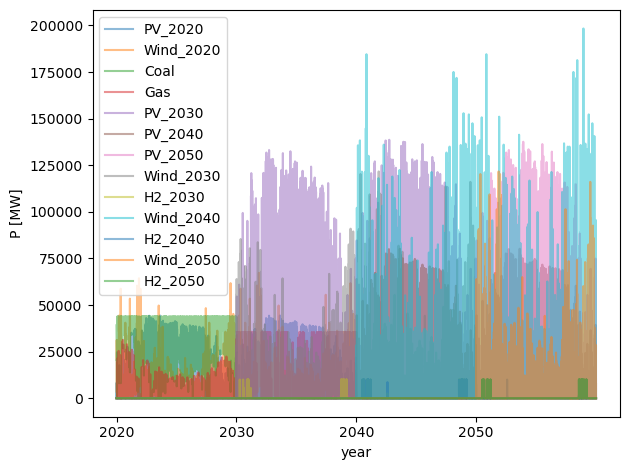

Der folgende Code zeigt die erzeugte Energie über den Investitionszeitraum.

<Axes: xlabel='Investment Period', ylabel='Generation'>

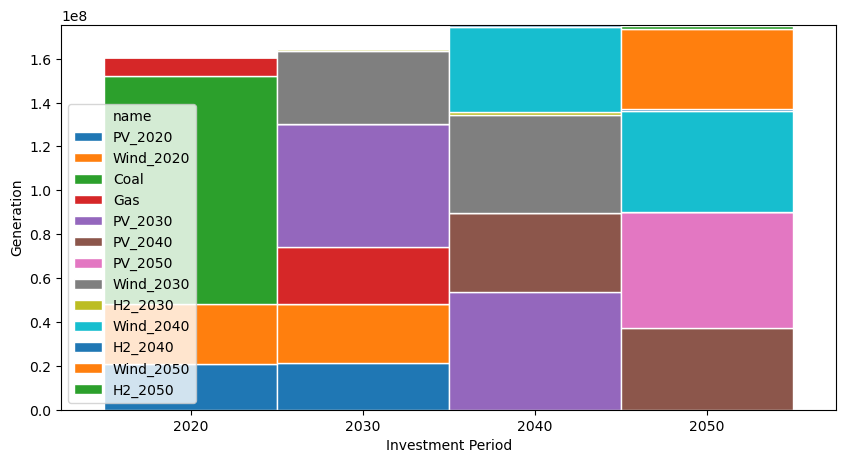

Der folgende Code zeigt die installierten Leistungen, über den Investitionszeitraum.

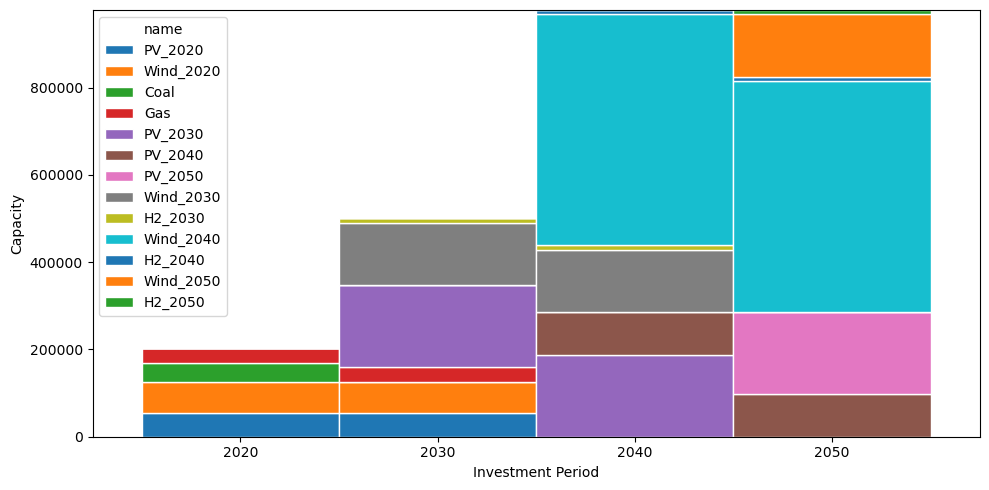